## HOUSE PREDICTION MODEL

In [1]:
import pandas as pd



In [2]:
housing = pd.read_csv("data.csv")

In [3]:
housing.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
housing["CHAS"].value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

In [6]:
housing.describe()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
%matplotlib inline

In [8]:
import matplotlib.pyplot as plt
import numpy as np

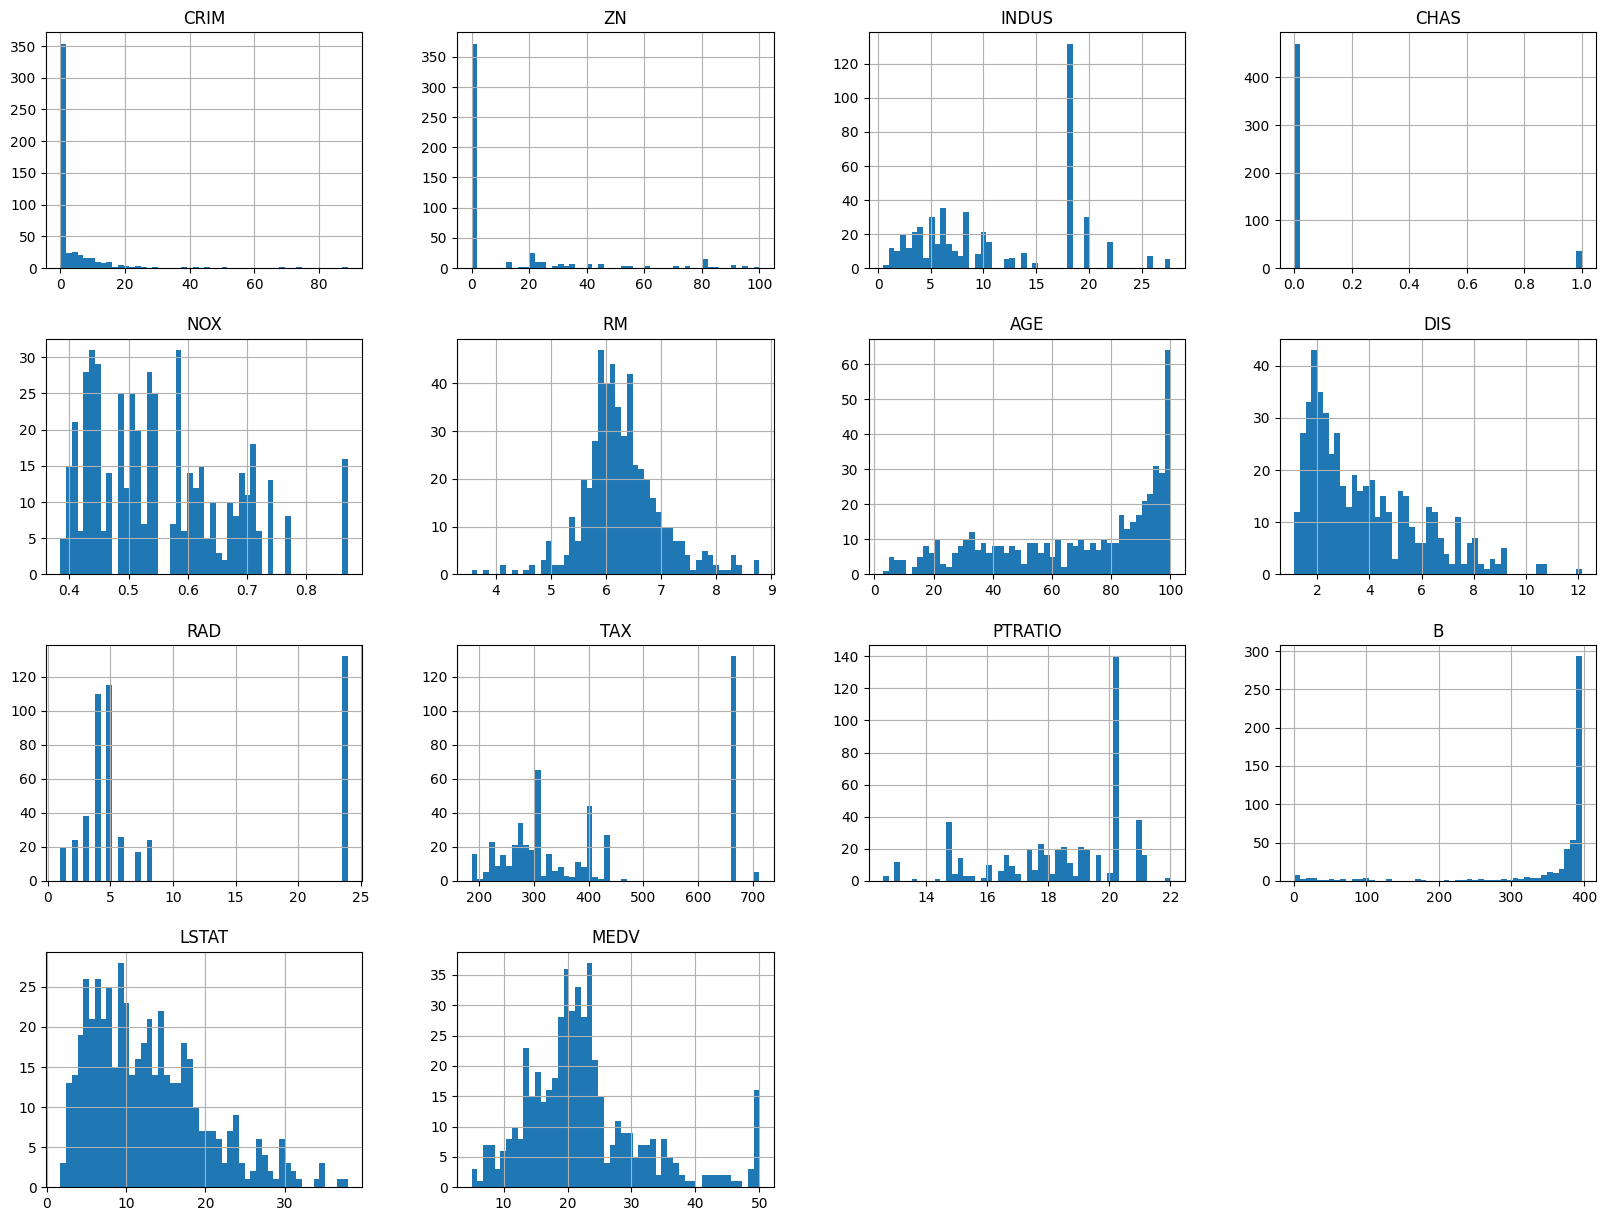

In [9]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [10]:
#plt.scatter(housing["MEDV"],housing["CRIM"])

## Train-Test splitting


In [11]:
from sklearn.model_selection import train_test_split 

In [12]:
#train, test = train_test_split( housing ,test_size=0.2,random_state=42)
#print(f"Rows in train set: {len(train)}\nRows in test set :{len(test)}")


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["CHAS"]):
    Strat_train_set = housing.loc[train_index]
    Strat_test_set  = housing.loc[test_index]


In [14]:
Strat_train_set.info()
Strat_test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404 entries, 254 to 216
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     404 non-null    float64
 1   ZN       404 non-null    float64
 2   INDUS    404 non-null    float64
 3   CHAS     404 non-null    int64  
 4   NOX      404 non-null    float64
 5   RM       404 non-null    float64
 6   AGE      404 non-null    float64
 7   DIS      404 non-null    float64
 8   RAD      404 non-null    int64  
 9   TAX      404 non-null    int64  
 10  PTRATIO  404 non-null    float64
 11  B        404 non-null    float64
 12  LSTAT    404 non-null    float64
 13  MEDV     404 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 47.3 KB
<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 342 to 218
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     102 non-null    float64
 1   ZN       102 non-

In [15]:
corr_matrix = housing.corr()
#print(corr_matrix)

In [16]:
corr_matrix['MEDV'].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

array([[<Axes: xlabel='MEDV', ylabel='MEDV'>,
        <Axes: xlabel='RM', ylabel='MEDV'>,
        <Axes: xlabel='ZN', ylabel='MEDV'>,
        <Axes: xlabel='LSTAT', ylabel='MEDV'>],
       [<Axes: xlabel='MEDV', ylabel='RM'>,
        <Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='ZN', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>],
       [<Axes: xlabel='MEDV', ylabel='ZN'>,
        <Axes: xlabel='RM', ylabel='ZN'>,
        <Axes: xlabel='ZN', ylabel='ZN'>,
        <Axes: xlabel='LSTAT', ylabel='ZN'>],
       [<Axes: xlabel='MEDV', ylabel='LSTAT'>,
        <Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='ZN', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>]], dtype=object)

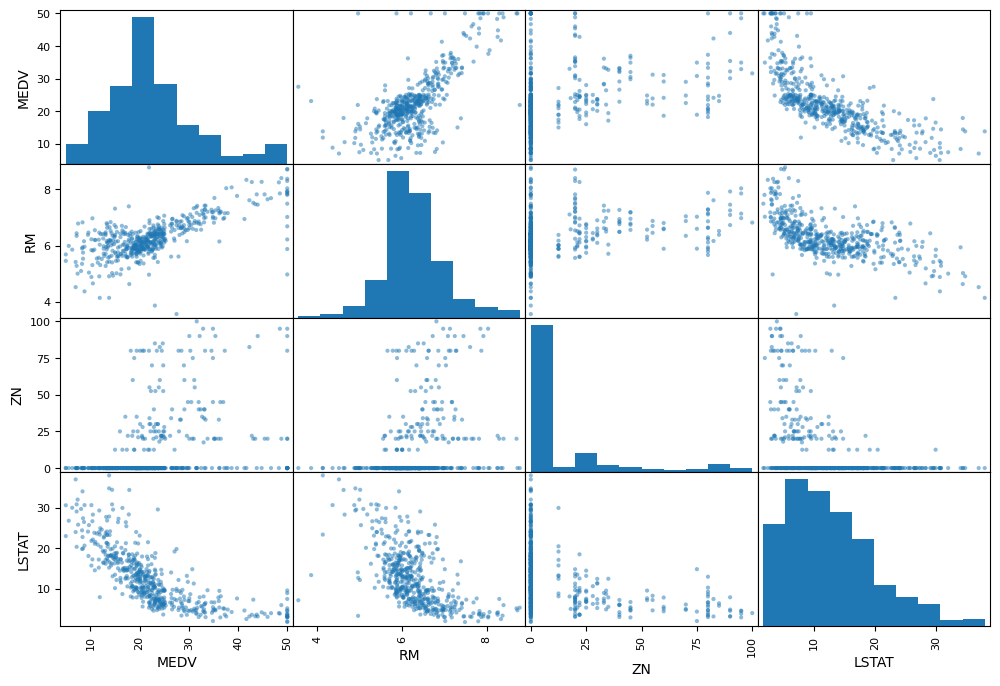

In [17]:
from pandas.plotting import scatter_matrix
attr = ['MEDV','RM','ZN','LSTAT']
scatter_matrix(housing[attr], figsize=(12,8))

In [18]:
housing = Strat_train_set.drop('MEDV', axis=1)
housing_labels= Strat_train_set['MEDV'].copy()

In [19]:
housing.shape


(404, 13)

In [20]:
#from sklearn.impute import SimpleImputer
#imputer = SimpleImputer(strategy="mean")
#imputer.fit(housing)

In [21]:
#imputer.statistics_

Feature Scaling
Two types of feature scaling
1. Min Max Scaling (Normalization) = (value-min)/(Max-min) sklearn provide a class called MinMaxScaler
2. Standardization = (Value- min)/std  sklearn  provide a class called StandardScaler.

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
my_pipeline = Pipeline([('imputer',SimpleImputer(strategy='median')),('std_scaler', StandardScaler())])

In [23]:
housing_tr= my_pipeline.fit_transform(housing)


In [24]:
#data= np.array([[0.02731,0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14]])



In [25]:
#house= my_pipeline.transform(data)

In [26]:
housing_tr.shape

(404, 13)

In [27]:
housing_tr[1]

array([-0.44352175,  3.12628155, -1.35893781, -0.27288841, -1.0542567 ,
        0.49865392, -1.3938808 ,  2.19312325, -0.65766683, -0.78557904,
       -0.69277865,  0.39131918, -0.94116739])

MODEL SELECTION

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
#model = LinearRegression()
#model=  DecisionTreeRegressor()
model=  RandomForestRegressor()
model.fit(housing_tr, housing_labels)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## EVALUATING THE MODEL

In [29]:
from sklearn.metrics import mean_squared_error
housing_predict = model.predict(housing_tr)
print(list(housing_predict[:5]))
housing_labels[:5]

[np.float64(22.44500000000002), np.float64(25.540999999999993), np.float64(16.414000000000016), np.float64(23.36099999999997), np.float64(23.630999999999993)]


254    21.9
348    24.5
476    16.7
321    23.1
326    23.0
Name: MEDV, dtype: float64

In [30]:
#plt.scatter(housing_predict, housing_labels, color='orange',edgecolor='blue', alpha=0.5, marker='^',s=50)
#plt.xlabel('housing_predict')
#plt.ylabel('housing_labels')



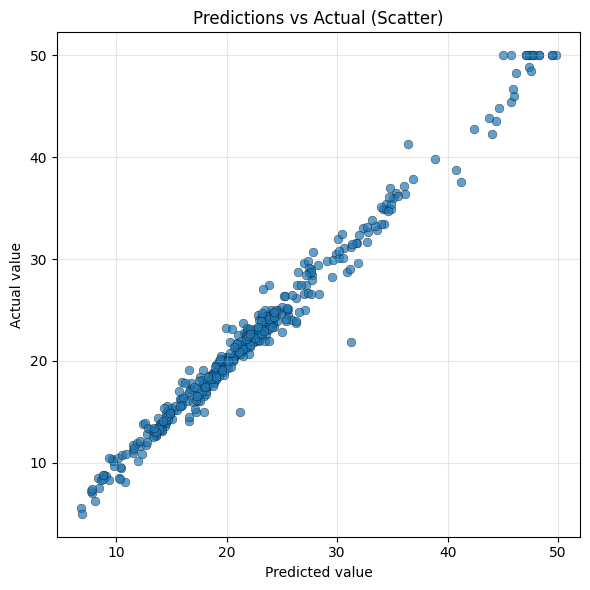

In [31]:

plt.figure(figsize=(6, 6))
plt.scatter(housing_predict, housing_labels, 
            marker='o',           # <-- marker, not color
            color='#1f77b4',      # set a color, or use cmap with c=...
            s=40,                 # point size
            alpha=0.7,            # transparency
            edgecolor='k',        # thin outline for clarity
            linewidth=0.3)



plt.xlabel('Predicted value')
plt.ylabel('Actual value')
plt.title('Predictions vs Actual (Scatter)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [32]:
mse = mean_squared_error(housing_labels, housing_predict)
rmse= np.sqrt(mse)
print(mse)
print(rmse)

1.5698555099009885
1.2529387494610376


## Better Evaluation Technique = Cross Validation

In [33]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(model, housing_tr, housing_labels, scoring="neg_root_mean_squared_error",cv=10 )
rmse_score= -score
rmse_score


array([2.78004364, 2.72474101, 4.54874381, 2.73689604, 3.5293897 ,
       2.56771228, 4.90296282, 3.28669052, 3.43155161, 3.38798118])

In [34]:
print("Scores:", rmse_score)
print("Mean:", rmse_score.mean())
print("Standard deviation:", rmse_score.std())

Scores: [2.78004364 2.72474101 4.54874381 2.73689604 3.5293897  2.56771228
 4.90296282 3.28669052 3.43155161 3.38798118]
Mean: 3.3896712609275257
Standard deviation: 0.7470537961662409


In [35]:

r2_scores = cross_val_score(model, housing_tr, housing_labels,
                            scoring="r2", cv=10)

print("Scores:", r2_scores )
print("Mean:", r2_scores.mean())
print("Standard deviation:", r2_scores.std())


Scores: [0.87417555 0.90426593 0.70017935 0.91624511 0.87954881 0.86732521
 0.83634136 0.90734279 0.77435785 0.90367455]
Mean: 0.8563456512556977
Standard deviation: 0.06573580247387843


## Saving the model

In [36]:
from joblib import dump, load
dump(model, 'Dragon.joblib')

['Dragon.joblib']

TESTING THE MODEL


In [37]:
X_test = Strat_test_set.drop("MEDV", axis = 1)
Y_test = Strat_test_set["MEDV"].copy()
X_test_prepared = my_pipeline.transform(X_test)
final_predictions = model.predict(X_test_prepared)
final_mse = mean_squared_error(final_predictions, Y_test)
final_rmse = np.sqrt(final_mse)
final_rmse

np.float64(2.915796563212051)

In [38]:
import numpy as np
from joblib import dump, load
model = load('Dragon.joblib')
features = np.array([[0.44352175,  3.12628155, -1.35893781, -0.27288841, -1.0542567 ,
        0.49865392, -1.3938808 ,  2.19312325, -0.65766683, -0.78557904,
       -0.69277865,  0.39131918, -0.94116739]])
model.predict(features)

array([28.807])